Esta versión está desactualizada

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# EDA

In [3]:
df_classes = pd.read_csv('./CSVs/classes.csv')
# df_wclasses = pd.read_csv('./CSVs/wclasses.csv')    # Asigna IDs numéricos

In [4]:
df_classes.head()

,filename,artist,genre,description,phash,width,height,genre_count,subset
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,['Abstract Expressionism'],acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,['Abstract Expressionism'],chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,['Abstract Expressionism'],gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train
3,Abstract_Expressionism/aaron-siskind_jerome-ar...,aaron siskind,['Abstract Expressionism'],jerome-arizona-1949,a5d691f85ac5e4d0,1382,1849,1,train
4,Abstract_Expressionism/aaron-siskind_kentucky-...,aaron siskind,['Abstract Expressionism'],kentucky-4-1951,880df359e6b11db1,1382,1625,1,train


## Análisis de columnas

### `artist`

In [6]:
total_artists = df_classes['artist'].nunique()
print(f"Hay {total_artists} artistas únicos.")

Hay 1119 artistas únicos.


Guardado en un txt por si se necesita revisión manual en algún momento.

In [7]:
artist_counts = df_classes['artist'].value_counts()

with open('./outputs/artists_count.txt', 'w', encoding='utf-8') as f:
    f.write(artist_counts.to_string())

### `genre`

In [8]:
total_genres = df_classes['genre'].nunique()
print(f"Hay {total_genres} géneros únicos.")

Hay 114 géneros únicos.


Guardado en un txt por si se necesita revisión manual en algún momento.

In [9]:
genres_counts = df_classes['genre'].value_counts()

with open('./outputs/genres_count.txt', 'w', encoding='utf-8') as f:
    f.write(genres_counts.to_string())

- En el análisis manual se observa un problema de etiquetas multiclase en formato de lista. Ejemplo:

MOVIMIENTO                                | CANTIDAD
------------------------------------------|----------
[Symbolism]                                 |   4174
[Symbolism, Art Nouveau Modern]             |    101
[Symbolism, Expressionism]                  |     91

**Decisión:**

### `width` x `height`

In [10]:
widths = df_classes['width'].tolist()
heights = df_classes['height'].tolist()

print(f"Anchos: {widths}")
print(f"Altos: {heights}")

Anchos: [1922, 1382, 1382, 1382, 1382, 1796, 1547, 1381, 1389, 1382, 1382, 1382, 1382, 1407, 1799, 1386, 1399, 1761, 2176, 1871, 1382, 1382, 1751, 2280, 1382, 1382, 1382, 2076, 2070, 1382, 1382, 1382, 1382, 1426, 1382, 1937, 1382, 2453, 1382, 1382, 2075, 1382, 1382, 1382, 1382, 1382, 2227, 1382, 2194, 1382, 2772, 1382, 1382, 1382, 2289, 1572, 2326, 2008, 1852, 1855, 1382, 1382, 2297, 2321, 1873, 1382, 1382, 1382, 1382, 1382, 1766, 1794, 1522, 1718, 1783, 1831, 1629, 1558, 2149, 1753, 1753, 1775, 1797, 1703, 1631, 1670, 1769, 1935, 1567, 1739, 1886, 1883, 1382, 2066, 1382, 1382, 1382, 1382, 1382, 1382, 1382, 1382, 1382, 1457, 1382, 1881, 1985, 1809, 1382, 1382, 1941, 1382, 1382, 1842, 1907, 1829, 1614, 1608, 2324, 1382, 1642, 1382, 1764, 1764, 1764, 1764, 1382, 1382, 1382, 1382, 1382, 1382, 1391, 1382, 1382, 1382, 1382, 1487, 1382, 1382, 1382, 1382, 1382, 1382, 1692, 1382, 1799, 1908, 1382, 1740, 1382, 1381, 1382, 2078, 1976, 1679, 1925, 1614, 5956, 1382, 3561, 5683, 1736, 1422, 1382, 2

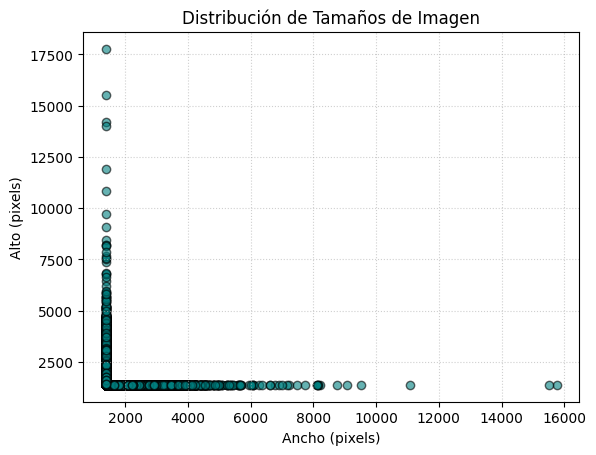

In [11]:
plt.scatter(widths, heights, alpha=0.6, color='teal', edgecolors='black')

plt.title('Distribución de Tamaños de Imagen')
plt.xlabel('Ancho (pixels)')
plt.ylabel('Alto (pixels)')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Se define una funión que grafique la dispersión filtrando por el artista o el género de la pintura.

In [12]:
def plot_artwork_dispersion(df, artist=None, genre=None):
    """
    Grafica la dispersión de width vs height filtrando por artista O género.
    """
    # Validar que solo se use un criterio
    if (artist is not None and genre is not None) or (artist is None and genre is None):
        raise ValueError("Debes proporcionar exactamente un artista o un género, pero no ambos.")
    
    if artist:
        # Filtrado por artista (insensible a mayúsculas/minúsculas)
        subset = df[df['artist'].str.lower() == artist.lower()]
        label = artist
    else:
        # Filtrado por género (buscando la palabra dentro de la lista-string)
        subset = df[df['genre'].str.contains(genre, case=False, na=False)]
        label = genre
    
    if subset.empty:
        print(f"No se encontraron datos para: {label}")
        return

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    plt.scatter(subset['width'], subset['height'], alpha=0.6, edgecolors='none', c='royalblue')
    
    plt.title(f'Dispersión de dimensiones: {label}')
    plt.xlabel('Width (Ancho)')
    plt.ylabel('Height (Alto)')
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Guardar la imagen
    filename = f"dispersion_{label.replace(' ', '_').lower()}.png"
    # plt.savefig(filename)
    plt.show()
    print(f"Gráfico generado: {filename}")

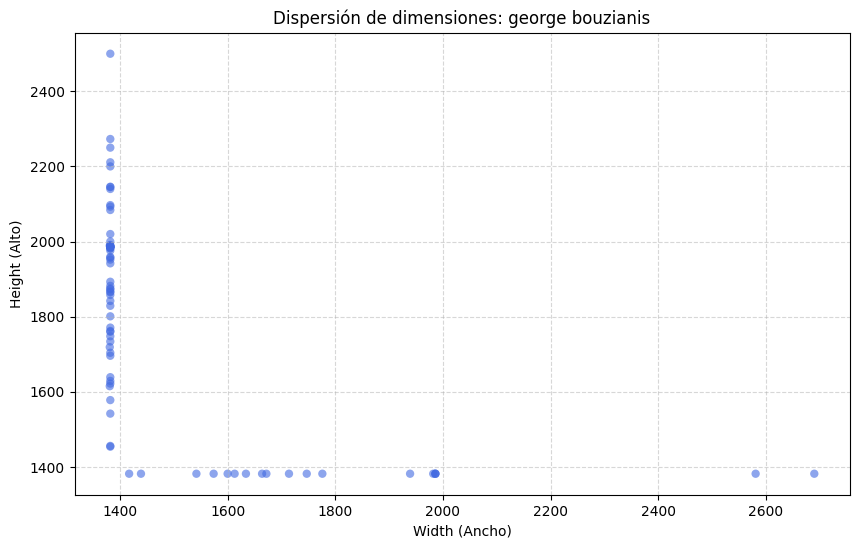

Gráfico generado: dispersion_george_bouzianis.png


In [13]:
# 1. Por artista
plot_artwork_dispersion(df_classes, artist="george bouzianis")

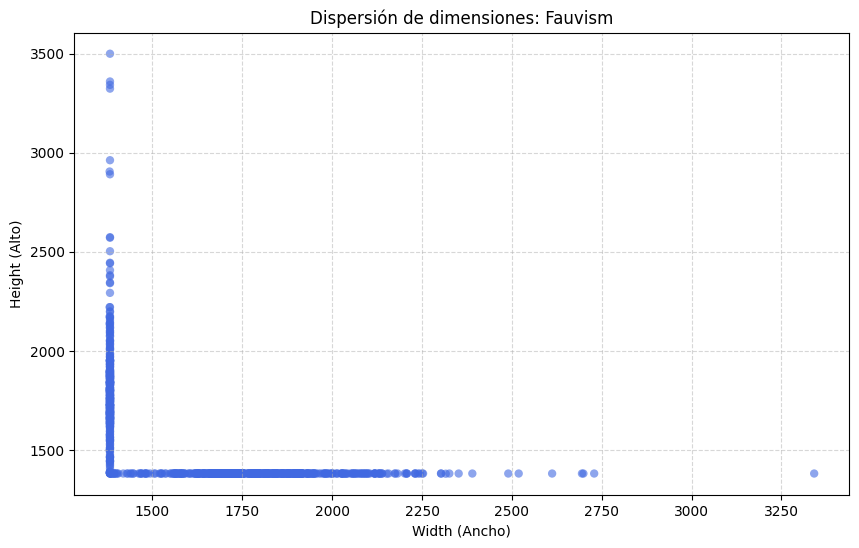

Gráfico generado: dispersion_fauvism.png


In [14]:
# 2. Por género
plot_artwork_dispersion(df_classes, genre='Fauvism')

In [19]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# --- Enhanced Data Augmentation for Training ---
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Standard Transform for Validation/Test ---
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- Load Dataset ---
dataset = datasets.ImageFolder("/kaggle/input", transform=None)

# --- Split Dataset ---
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# --- Apply Different Transforms ---
train_ds.dataset.transform = train_transform
val_ds.dataset.transform = val_test_transform
test_ds.dataset.transform = val_test_transform

# --- Optimized DataLoader for Multi-GPU Training ---
# Calculate optimal batch size for 2 GPUs
BATCH_SIZE = 128  # Split across 2 GPUs (64 per GPU) - increase to 256 if memory allows

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,  # 2 workers per GPU
    pin_memory=True,  # Faster CPU-to-GPU transfer
    prefetch_factor=3,  # Prefetch 3 batches per worker
    persistent_workers=True  # Reuse workers between epochs
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=3,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    prefetch_factor=3,
    persistent_workers=True
)

print(f"Dataset: {len(dataset)} images")
print(f"Train: {train_size} | Val: {val_size} | Test: {test_size}")
print(f"Classes: {len(dataset.classes)}")
print(f"Batch size: {BATCH_SIZE} (split across 2 GPUs)")
print(f"Workers: 4 (2 per GPU)")
print("DataLoader optimized for maximum throughput!")

OSError: [WinError 1114] Error en una rutina de inicialización de biblioteca de vínculos dinámicos (DLL). Error loading "c:\Users\José Luis\.pyenv\pyenv-win\versions\3.11.7\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.